In [21]:
import pandas as pd
import numpy as np
import re
import os
import requests
from joblib import load

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             precision_score, roc_auc_score, roc_curve)
from sklearn.calibration import CalibratedClassifierCV                             
#from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

import seaborn as sns
import matplotlib.pyplot as plt

from preprocessor import *
from Preprocessor_LLM import *
from Preprocessor_LLM_RAG import *



## 1. Chargement des données

In [22]:
data = pd.read_csv('~/work/PROJET_STATAPP/Data/Cleans/Data_for_active_learning.csv')

X = data.drop(columns=['FraudFound_P'])
y = data['FraudFound_P']

## 2. Preprocessing

In [23]:
# Preprocesseur numérique (pour les modèles ML)
preprocessor = load("preprocessor.joblib")
print("✓ Preprocessor numérique chargé")

# Preprocesseur textuel (pour le LLM)
preprocessor_llm = PreprocessLLM(
    label_cols=label_cols,
    freq_cols=freq_cols,
    ordinal_cols=ordinal_cols,
    binary_cols=binary_cols,
    scale_cols=scale_cols
)

# Preprocesseur RAG (exemples déjà labelisés)
Fraud_col = "FraudFound_P"
preprocessor_llm_rag = PreprocessLLM_RAG(
    label_cols=label_cols,
    freq_cols=freq_cols,
    ordinal_cols=ordinal_cols,
    binary_cols=binary_cols,
    scale_cols=scale_cols,
    Fraud_col=Fraud_col
)

all_cols = binary_cols + label_cols + freq_cols + ordinal_cols + scale_cols
X_preprocessed = preprocessor.fit_transform(X)
X_preprocessed = pd.DataFrame(X_preprocessed, columns=all_cols)
X_raw = X.copy()

print(f"  Données numériques : {X_preprocessed.shape}")
print(f"  Données brutes (pour LLM) : {X_raw.shape}")

# Vérification du format LLM
exemple_text = preprocessor_llm.transform(X_raw.head(1))
print("\n Exemple preprocessing LLM :")
print(exemple_text[0]['text'])


✓ Preprocessor numérique chargé
  Données numériques : (15419, 20)
  Données brutes (pour LLM) : (15419, 21)

 Exemple preprocessing LLM :
Âge : 21 ans
Délai avant déclaration : 1 semaines
Sexe : Female
Zone de l'accident : Urban
Responsabilité : Policy Holder
Rapport de police : No
Présence de témoins : No
Type d'agent : External
VehiclePrice : more than 69000
Days_Policy_Accident : more than 30
PastNumberOfClaims : none
AgeOfVehicle : 3 years
NumberOfSuppliments : none
AddressChange_Claim : 1 year
NumberOfCars : 3 to 4
DriverRating : 1
Deductible : 300
PolicyType : Sport - Liability
Make : Honda
MaritalStatus : Single


## 3. Split train / pool / test

In [24]:
# 20% réservé au test
X_pool_full, X_test, y_pool_full, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, stratify=y, random_state=42
)
X_raw_pool_full, X_raw_test, _, _ = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

# Seed initial : 300 observations labelisées
X_init, X_pool, y_init, y_pool = train_test_split(
    X_pool_full, y_pool_full, train_size=300, stratify=y_pool_full, random_state=42
)
X_raw_init, X_raw_pool, _, _ = train_test_split(
    X_raw_pool_full, y_pool_full, train_size=300, stratify=y_pool_full, random_state=42
)

# Copies indépendantes par stratégie
X_init_US,  X_pool_US,  y_init_US,  y_pool_US   = X_init.copy(),  X_pool.copy(),  y_init.copy(),  y_pool.copy()
X_init_LLM, X_pool_LLM, y_init_LLM, y_pool_LLM  = X_init.copy(),  X_pool.copy(),  y_init.copy(),  y_pool.copy()
X_raw_pool_LLM = X_raw_pool.copy()

print(f"  Test set   : {len(X_test):>6} observations")
print(f"  Seed init  : {len(X_init):>6} observations ({len(X_init)/len(X_pool_full)*100:.1f}%)")
print(f"  Pool actif : {len(X_pool):>6} observations")


  Test set   :   3084 observations
  Seed init  :    300 observations (2.4%)
  Pool actif :  12035 observations


## 4. Configuration API Mistral & hyperparamètres

In [25]:
# ── API Mistral ──────────────────────────────────────────────────────────────
API_KEY   = os.environ.get("MISTRAL_API_KEY", "eUxAoQ7PZYmdYBvTqNjR3cGxIdEGi1Ky")  # préférer variable d'env
API_URL   = "https://api.mistral.ai/v1/chat/completions"
gpu_model = "mistral-small-latest"   # options : mistral-small-latest | mistral-large-latest

# ── Hyperparamètres active learning ─────────────────────────────────────────
n_preselect    = 300   # candidats présélectionnés aléatoirement pour le LLM
n_llm_select   = 100   # le LLM choisit parmi les candidats (doit être > n_select)
n_select       = 50    # observations finalement ajoutées à chaque itération
label_max      = 2000  # budget total de labels
temperature    = 0.1   # température du LLM (faible = déterministe)
n_rag          = 30    # nombre d'exemples déjà labelisés passés au LLM (RAG)
methode        = "COT_conflict"

assert n_llm_select > n_select, "n_llm_select doit être > n_select pour appliquer le filtre de conflit"
print("✓ Configuration OK")
print(f"  Stratégie de conflit : LLM sélectionne {n_llm_select} → filtre probas → {n_select} finaux (milieu)")


✓ Configuration OK
  Stratégie de conflit : LLM sélectionne 100 → filtre probas → 50 finaux (milieu)


## 5. Initialisation des modèles

In [26]:
lgbm_params = dict(learning_rate=0.05, max_depth=10, n_estimators=300,
                   random_state=42, min_child_samples=5, verbose=-1)

model     = LGBMClassifier(**lgbm_params)   # Random Sampling
model_US  = LGBMClassifier(**lgbm_params)   # Uncertainty Sampling
model_LLM = LGBMClassifier(**lgbm_params)   # LLM Sampling

#scale_pos_weight
spw = (y_init == 0).sum() / (y_init == 1).sum()
model.set_params(scale_pos_weight=spw)
model.fit(X_init, y_init)

spw_US = (y_init_US == 0).sum() / (y_init_US == 1).sum()
model_US.set_params(scale_pos_weight=spw_US)
model_US.fit(X_init_US, y_init_US)

spw_LLM = (y_init_LLM == 0).sum() / (y_init_LLM == 1).sum()
model_LLM.set_params(scale_pos_weight=spw_LLM)
model_LLM.fit(X_init_LLM, y_init_LLM)

#smote = SMOTE(sampling_strategy=0.25, random_state=42)


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,5


## 6. Fonctions utilitaires

In [14]:
# ── Mise en forme texte pour le LLM ─────────────────────────────────────────

def enumerate_observations(text_samples):
    """Formate les observations labelisées (RAG)."""
    out = ""
    for i, sample in enumerate(text_samples):
        out += f"--- Observation {i} ---\n{sample['text']}\n\n"
    return out


def create_summary_for_llm(text_samples):
    """Formate les candidats non-labelisés à évaluer par le LLM."""
    n = len(text_samples)
    summary = f"You have {n} pre-selected samples.\n\nSamples:\n\n"
    for i, sample in enumerate(text_samples):
        summary += f"--- Sample {i} ---\n{sample['text']}\n\n"
    return summary


# ── Prompt CoT avec logique de tension ──────────────────────────────────────

def create_llm_prompt(text_samples, n_select=100):
    """
    Construit le prompt CoT pour le LLM.
    
    Le LLM est guidé vers une logique de TENSION (signaux contradictoires
    coexistants) plutôt qu'une simple accumulation de signaux suspects.
    Il retourne n_select indices ; un filtre par probabilités du modèle
    extrait ensuite les 50 observations de double incertitude.
    """
    summary = create_summary_for_llm(text_samples)

    prompt = f"""You are an expert in active learning for insurance fraud detection.

CONTEXT — Here are {len(text_samples)} pre-selected insurance claims.

{summary}

For each observation, look for the following signals:

  STRONG SIGNALS (suspicion indicators):
  - Late claim reporting (abnormally long delay_week)
  - No witness present
  - No police report
  - Profile/vehicle inconsistency (e.g., young driver + luxury car)
  - Many past claims
  - Driver at fault at the time of the incident

  NORMAL SIGNALS (legitimacy indicators):
  - Witness present and police report filed
  - Reasonable reporting delay
  - Profile consistent with vehicle
  - No prior claims

NOTE: Features are min-max normalized to [0, 1].

--- TASK ---
Your goal is NOT to find the most suspicious cases.
Your goal is to find the {n_select} observations where you are LEAST CERTAIN about the label.
Uncertainty arises when STRONG and NORMAL signals COEXIST in the same observation — 
these are cases where even an expert investigator would genuinely hesitate.

Reason in 4 steps:

Step 1 — Conflict scoring:
  Score ALL observations mentally, but display the result for the first 7 only.
  Format: <index>: strong=X, normal=Y, tension=True/False

Step 2 — Eliminate clearly fraudulent cases:
  Identify observations with many strong signals and virtually no normal signals.
  You are confident → less useful to annotate → exclude them.

Step 3 — Eliminate clearly legitimate cases:
  Identify observations with mostly normal signals and no strong signals.
  You are confident → less useful to annotate → exclude them.

Step 4 — Final selection:
  Select EXACTLY {n_select} indices (from 0 to {len(text_samples)-1}) that maximise TENSION.
  Prioritise observations where strong and normal signals actively contradict each other.
  Aim for DIVERSITY: cover different types of ambiguity (age/vehicle mismatch alone,
  absent witness alone, mixed signals on delay, etc.) rather than clustering on one pattern.

Respond STRICTLY in this format:

Step 1:
<conflict scoring — one line per observation>

Step 2:
<clearly fraudulent cases excluded> 

Step 3:
<clearly legitimate cases excluded>

Step 4 — Selected indices:
[3, 8, 21, ...]

IMPORTANT: the list in Step 4 must contain EXACTLY {n_select} integers, no more, no less.
"""
    return prompt


# ── Appel API Mistral ────────────────────────────────────────────────────────

def reponse_llm(prompt_value, api_url, llm_model, temperature, api_key):
    """Envoie le prompt à l'API Mistral et retourne la réponse texte."""
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }
    payload = {
        "model": llm_model,
        "messages": [{"role": "user", "content": prompt_value}],
        "temperature": temperature,
        "stream": False
    }
    response = requests.post(api_url, headers=headers, json=payload, timeout=120)
    response.raise_for_status()
    return response.json()["choices"][0]["message"]["content"]


# ── Parsing de la réponse LLM ────────────────────────────────────────────────

def parse_llm_response(llm_output, n_max, expected_n):
    """
    Extrait la liste d'indices de la réponse du LLM.
    
    - Cherche le dernier bloc [...] (celui du Step 4).
    - Filtre les indices hors bornes et les doublons.
    - Complète par tirage aléatoire si la liste est trop courte.
    """
    matches = re.findall(r'\[[\d,\s]+\]', llm_output)
    if not matches:
        print("  ⚠ Aucune liste trouvée dans la réponse LLM → fallback aléatoire")
        return list(np.random.choice(n_max, size=min(expected_n, n_max), replace=False))

    # Prendre le dernier match (= Step 4)
    raw_indices = eval(matches[-1])
    indices = list(dict.fromkeys(           # dédoublonnage ordre-préservant
        int(i) for i in raw_indices
        if isinstance(i, (int, float)) and 0 <= int(i) < n_max
    ))

    if len(indices) < expected_n:
        print(f"  ⚠ Seulement {len(indices)} indices valides, complétion aléatoire")
        remaining = [i for i in range(n_max) if i not in indices]
        np.random.shuffle(remaining)
        indices.extend(remaining[:expected_n - len(indices)])

    print(f"  ✓ {len(indices)} indices extraits du LLM")
    return indices[:expected_n]


# ── Filtre de conflit LLM × modèle ──────────────────────────────────────────

def apply_conflict_filter(llm_indices, model_probas_on_preselect, n_final):
    """
    Stratégie de double incertitude (conflit LLM × modèle) :
    
    Le LLM a sélectionné n_llm_select observations qu'il juge incertaines.
    Parmi elles, on trie par probabilité prédite par le modèle et on garde
    les n_final du MILIEU, i.e. celles où le modèle est lui aussi le plus
    incertain.
    
    Les extrêmes (proba très basse ou très haute) correspondent à des cas
    où le LLM hésite mais le modèle est confiant → moins intéressant.
    
    Args:
        llm_indices        : indices (dans la présélection) choisis par le LLM
        model_probas_on_preselect : probas du modèle sur les n_preselect candidats
        n_final            : nombre d'indices à retourner
    
    Returns:
        Liste de n_final indices (dans la présélection) correspondant à la
        zone de double incertitude.
    """
    n_llm = len(llm_indices)
    assert n_llm >= n_final, "n_llm_select doit être ≥ n_select"

    llm_probas = model_probas_on_preselect[llm_indices]

    # Trier par probabilité croissante
    sorted_order = np.argsort(llm_probas)          # indices dans llm_indices
    sorted_llm_indices = np.array(llm_indices)[sorted_order]

    # Garder le milieu (double incertitude)
    margin = (n_llm - n_final) // 2
    middle_slice = sorted_llm_indices[margin: margin + n_final]

    print(f"  Conflit filter : {n_llm} → {len(middle_slice)} observations (milieu des probas)")
    print(f"  Plage probas retenues : [{llm_probas[sorted_order[margin]]:.3f}"
          f" – {llm_probas[sorted_order[margin + n_final - 1]]:.3f}]")

    return list(middle_slice)


print("✓ Fonctions utilitaires définies")


✓ Fonctions utilitaires définies


## 7. Boucle d'active learning

In [15]:
# ===========================
# BOUCLE D'ACTIVE LEARNING
# ===========================
results    = []
iteration  = 0
X_for_rag  = X_init.copy()
y_for_rag  = y_init.copy()

print("\n" + "="*60)
print("DÉBUT DE LA BOUCLE D'ACTIVE LEARNING")
print(f"Budget : {label_max} labels | Batch : {n_select} / itération")
print("="*60)

while len(X_init) < label_max and len(X_pool) > 0:
    iteration += 1
    print(f"\n{'='*60}")
    print(f"ITÉRATION {iteration:>3}  —  Labels disponibles : {len(X_init)}")
    print(f"{'='*60}")

    # ── Reset des index (crucial après suppressions) ──────────────────
    for df in [X_pool, y_pool, X_pool_US, y_pool_US,
               X_pool_LLM, X_raw_pool_LLM, y_pool_LLM]:
        df.reset_index(drop=True, inplace=True)

    # ── SMOTE ────────────────────────────────────────────────────────────
    # X_init_smote,     y_init_smote     = smote.fit_resample(X_init,     y_init)
    # X_init_US_smote,  y_init_US_smote  = smote.fit_resample(X_init_US,  y_init_US)
    # X_init_LLM_smote, y_init_LLM_smote = smote.fit_resample(X_init_LLM, y_init_LLM)

    # ── Entraînement ─────────────────────────────────────────────────────
    model.fit(X_init,     y_init)
    model_US.fit(X_init_US,  y_init_US)
    model_LLM.fit(X_init_LLM, y_init_LLM)

    # ── Évaluation sur le test set ────────────────────────────────────────
    def eval_model(m, X_t, y_t):
        pred  = m.predict(X_t)
        proba = m.predict_proba(X_t)[:, 1]
        return {
            "accuracy":  accuracy_score(y_t, pred),
            "f1":        f1_score(y_t, pred),
            "recall":    recall_score(y_t, pred),
            "precision": precision_score(y_t, pred),
            "auc":       roc_auc_score(y_t, proba)
        }

    res_rand = eval_model(model,     X_test, y_test)
    res_us   = eval_model(model_US,  X_test, y_test)
    res_llm  = eval_model(model_LLM, X_test, y_test)

    results.append({
        "labels_used": len(X_init),
        **{f"{k}_random_sampling":      v for k, v in res_rand.items()},
        **{f"{k}_uncertainty_sampling": v for k, v in res_us.items()},
        **{f"{k}_llm_sampling":         v for k, v in res_llm.items()},
    })

    print(f"  AUC — Random: {res_rand['auc']:.4f} | "
          f"US: {res_us['auc']:.4f} | LLM: {res_llm['auc']:.4f}")

    # ── Probabilités sur les pools ────────────────────────────────────────
    y_pool_proba     = model.predict_proba(X_pool)[:, 1]
    y_pool_US_proba  = model_US.predict_proba(X_pool_US)[:, 1]
    y_pool_LLM_proba = model_LLM.predict_proba(X_pool_LLM)[:, 1]

    # =========================================================
    # RANDOM SAMPLING
    # =========================================================
    print("\n[Random Sampling]")
    if len(X_pool) >= n_select:
        x_batch, X_pool, y_batch, y_pool = train_test_split(
            X_pool, y_pool, train_size=n_select, stratify=y_pool, random_state=iteration
        )
        X_init = pd.concat([X_init, x_batch], ignore_index=True)
        y_init = pd.concat([y_init, y_batch], ignore_index=True)
        print(f"  +{n_select} échantillons | Pool restant : {len(X_pool)}")
    else:
        print("  Pool épuisé"); break

    # =========================================================
    # UNCERTAINTY SAMPLING
    # =========================================================
    print("\n[Uncertainty Sampling]")
    if len(X_pool_US) > 0:
        # Seuil de Youden calculé sur les données d'entraînement
        y_init_US_proba = model_US.predict_proba(X_init_US)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_init_US, y_init_US_proba)
        youden_threshold = thresholds[np.argmax(tpr - fpr)]

        dist_to_threshold = np.abs(y_pool_US_proba - youden_threshold)
        query_idx = np.argsort(dist_to_threshold)[:min(n_select, len(X_pool_US))]

        X_init_US = pd.concat([X_init_US, X_pool_US.iloc[query_idx]], ignore_index=True)
        y_init_US = pd.concat([y_init_US, y_pool_US.iloc[query_idx]], ignore_index=True)

        mask = np.ones(len(X_pool_US), dtype=bool)
        mask[query_idx] = False
        X_pool_US = X_pool_US[mask].reset_index(drop=True)
        y_pool_US = y_pool_US[mask].reset_index(drop=True)

        print(f"  +{len(query_idx)} échantillons (seuil Youden : {youden_threshold:.4f})"
              f" | Pool restant : {len(X_pool_US)}")

    # =========================================================
    # LLM SAMPLING  (CoT + filtre de conflit LLM × modèle)
    # =========================================================
    print("\n[LLM Sampling — CoT + Conflict Filter]")

    if len(X_pool_LLM) == 0:
        print("  Pool épuisé"); continue

    try:
        n_pre  = min(n_preselect, len(X_pool_LLM))
        n_llm  = min(n_llm_select, n_pre)
        n_fin  = min(n_select, n_llm)

        # ÉTAPE 1 — Présélection aléatoire
        preselect_idx = np.random.choice(len(X_pool_LLM), size=n_pre, replace=False)
        X_raw_preselect  = X_raw_pool_LLM.iloc[preselect_idx].reset_index(drop=True)
        preselect_probas = y_pool_LLM_proba[preselect_idx]

        # ÉTAPE 2 — Le LLM choisit n_llm observations incertaines (CoT)
        print(f"  Présélection : {n_pre} candidats → LLM choisit {n_llm}")
        text_samples = preprocessor_llm.transform(X_raw_preselect)

        data_for_rag  = pd.concat(
            [X_for_rag.iloc[:n_rag], pd.DataFrame([y_for_rag]).iloc[:n_rag]],
            ignore_index=True
        )
        add_to_prompt = preprocessor_llm_rag.transform_rag(data_for_rag)

        prompt = (
            create_llm_prompt(text_samples, n_select=n_llm)
            + "\n\nHere are some already-labeled observations for reference "
              "('Fraud status': 1 = fraud, 0 = legitimate):\n\n"
            + enumerate_observations(add_to_prompt)
        )

        llm_output = reponse_llm(prompt, API_URL, gpu_model, temperature, API_KEY)

        print("\n── Réponse LLM ──────────────────────────────────────────")
        print(llm_output)
        print("─────────────────────────────────────────────────────────\n")

        llm_local_indices = parse_llm_response(llm_output, n_max=n_pre, expected_n=n_llm)

        # ÉTAPE 3 — Filtre de conflit : garder les 50 du milieu (double incertitude)
        final_local_indices = apply_conflict_filter(
            llm_local_indices, preselect_probas, n_final=n_fin
        )

        # ÉTAPE 4 — Reconversion en indices pool global
        final_query_idx = preselect_idx[final_local_indices]

        X_init_LLM = pd.concat([X_init_LLM, X_pool_LLM.iloc[final_query_idx]], ignore_index=True)
        y_init_LLM = pd.concat([y_init_LLM, y_pool_LLM.iloc[final_query_idx]], ignore_index=True)

        mask = np.ones(len(X_pool_LLM), dtype=bool)
        mask[final_query_idx] = False
        X_pool_LLM     = X_pool_LLM[mask].reset_index(drop=True)
        X_raw_pool_LLM = X_raw_pool_LLM[mask].reset_index(drop=True)
        y_pool_LLM     = y_pool_LLM[mask].reset_index(drop=True)

        print(f"  +{len(final_query_idx)} échantillons | Pool restant : {len(X_pool_LLM)}")

    except Exception as e:
        import traceback
        print(f"  ❌ ERREUR LLM : {e}")
        traceback.print_exc()

print("\n" + "="*60)
print("FIN DE LA BOUCLE D'ACTIVE LEARNING")
print("="*60)



DÉBUT DE LA BOUCLE D'ACTIVE LEARNING
Budget : 2000 labels | Batch : 50 / itération

ITÉRATION   1  —  Labels disponibles : 300
  AUC — Random: 0.6937 | US: 0.6937 | LLM: 0.6937

[Random Sampling]
  +50 échantillons | Pool restant : 11985

[Uncertainty Sampling]
  +50 échantillons (seuil Youden : 0.9956) | Pool restant : 11985

[LLM Sampling — CoT + Conflict Filter]
  Présélection : 300 candidats → LLM choisit 100

── Réponse LLM ──────────────────────────────────────────
Step 1:
0: strong=4, normal=1, tension=True
1: strong=3, normal=1, tension=True
2: strong=3, normal=1, tension=True
3: strong=2, normal=2, tension=True
4: strong=2, normal=2, tension=True
5: strong=2, normal=2, tension=True
6: strong=2, normal=2, tension=True

Step 2:
<clearly fraudulent cases excluded>
[12, 16, 20, 21, 25, 36, 46, 51, 55, 64, 67, 79, 84, 86, 90, 99, 100, 107, 115, 121, 123, 136, 147, 153, 158, 166, 172, 186, 196, 203, 212, 215, 223, 236, 243, 253, 263, 271, 281, 287, 291]

Step 3:
<clearly legitimate

## 8. Résultats

In [16]:
results_df = pd.DataFrame(results)
display(results_df.tail(10))

# Sauvegarde CSV
save_path = f"~/work/PROJET_STATAPP/Notebooks/sorties/resultsCOT_spw_{methode}_{gpu_model}_{n_preselect}_{label_max}.csv"
results_df.to_csv(save_path, index=False)
print(f"✓ Résultats sauvegardés : {save_path}")


,labels_used,accuracy_random_sampling,f1_random_sampling,recall_random_sampling,precision_random_sampling,auc_random_sampling,accuracy_uncertainty_sampling,f1_uncertainty_sampling,recall_uncertainty_sampling,precision_uncertainty_sampling,auc_uncertainty_sampling,accuracy_llm_sampling,f1_llm_sampling,recall_llm_sampling,precision_llm_sampling,auc_llm_sampling
24,1500,0.910506,0.142857,0.124324,0.167883,0.761215,0.927691,0.145594,0.102703,0.250000,0.734587,0.861219,0.207407,0.302703,0.157746,0.773437
25,1550,0.914073,0.164038,0.140541,0.196970,0.765794,0.927043,0.150943,0.108108,0.250000,0.742034,0.866732,0.201942,0.281081,0.157576,0.772757
26,1600,0.916018,0.188088,0.162162,0.223881,0.769369,0.927367,0.151515,0.108108,0.253165,0.730763,0.865110,0.193798,0.270270,0.151057,0.774632
27,1650,0.910830,0.169184,0.151351,0.191781,0.767940,0.926394,0.149813,0.108108,0.243902,0.732883,0.864786,0.193424,0.270270,0.150602,0.777306
28,1700,0.907588,0.164223,0.151351,0.179487,0.761198,0.927367,0.170370,0.124324,0.270588,0.732961,0.865435,0.224299,0.324324,0.171429,0.781295
29,1750,0.910182,0.147692,0.129730,0.171429,0.759643,0.923476,0.163121,0.124324,0.237113,0.740274,0.864137,0.201905,0.286486,0.155882,0.792711
30,1800,0.908885,0.151057,0.135135,0.171233,0.753934,0.923476,0.169014,0.129730,0.242424,0.740089,0.861219,0.204461,0.297297,0.155807,0.782687
31,1850,0.910506,0.183432,0.167568,0.202614,0.765244,0.922503,0.173010,0.135135,0.240385,0.721074,0.864786,0.202677,0.286486,0.156805,0.783857
32,1900,0.911479,0.138801,0.118919,0.166667,0.750969,0.920558,0.186047,0.151351,0.241379,0.739634,0.868353,0.194444,0.264865,0.153605,0.779919
33,1950,0.910182,0.163142,0.145946,0.184932,0.751253,0.922827,0.195946,0.156757,0.261261,0.729347,0.866407,0.198444,0.275676,0.155015,0.779654


✓ Résultats sauvegardés : ~/work/PROJET_STATAPP/Notebooks/sorties/resultsCOT_spw_COT_conflict_mistral-small-latest_300_2000.csv


## 9. Visualisation

✓ Graphique sauvegardé : ~/work/PROJET_STATAPP/Notebooks/sorties/al_results_spw_COT_conflict_mistral-small-latest_300_2000_T0.1.png


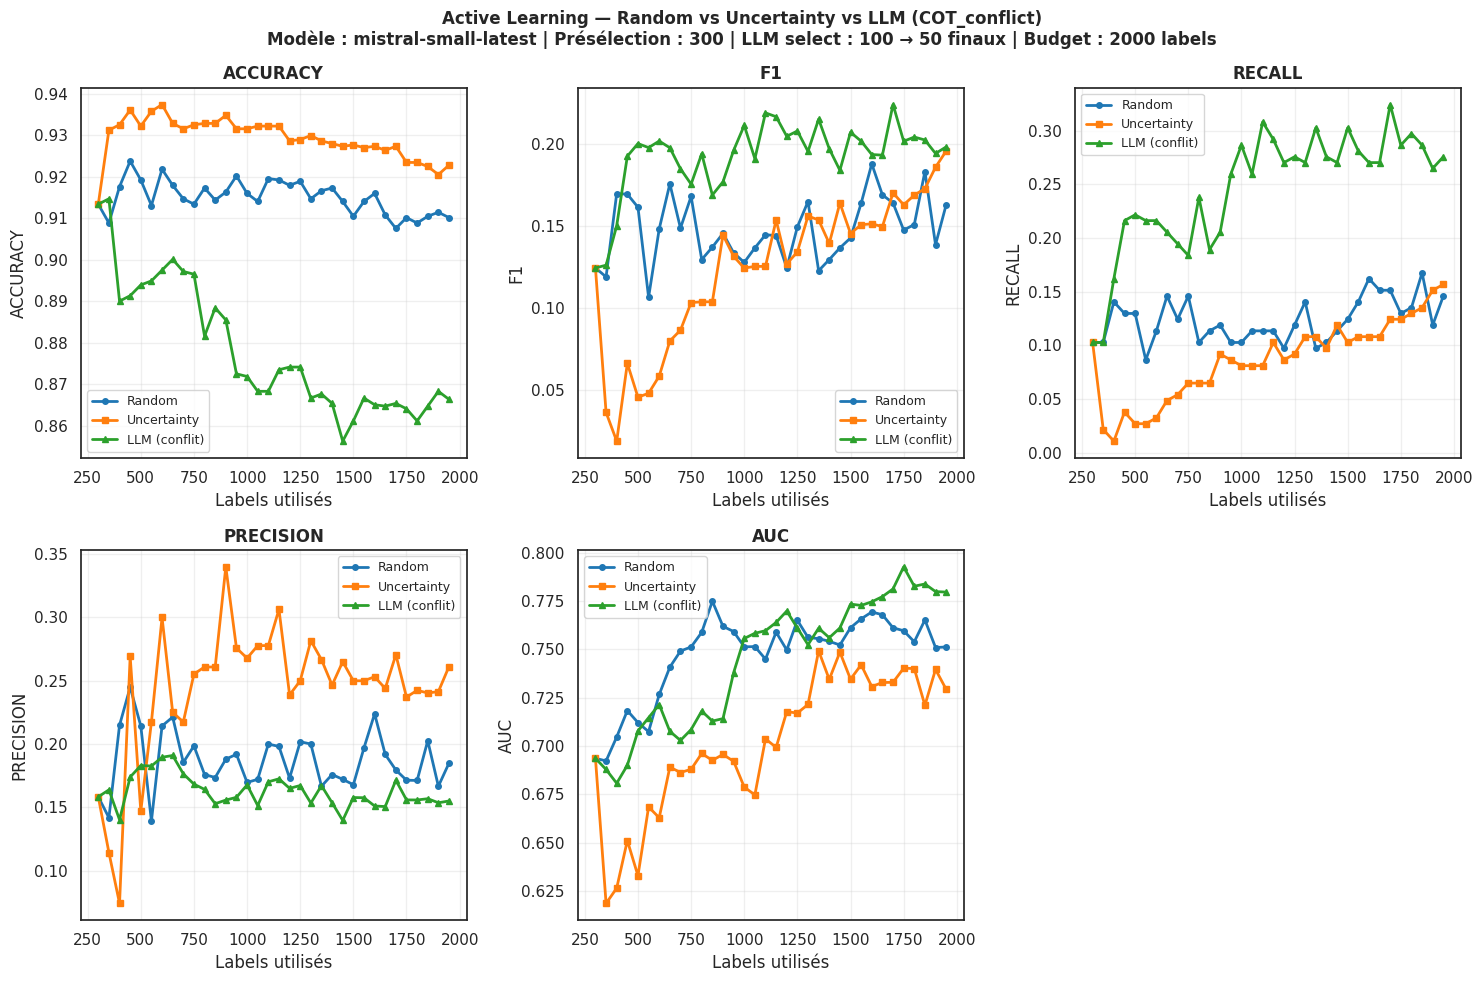

In [17]:
sns.set_theme(style="white", palette="deep", font_scale=1.0)

metrics = ["accuracy", "f1", "recall", "precision", "auc"]
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c']
labels  = ["Random", "Uncertainty", "LLM (conflit)"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.plot(results_df["labels_used"], results_df[f"{metric}_random_sampling"],
            'o-', label=labels[0], color=colors[0], linewidth=2, markersize=4)
    ax.plot(results_df["labels_used"], results_df[f"{metric}_uncertainty_sampling"],
            's-', label=labels[1], color=colors[1], linewidth=2, markersize=4)
    ax.plot(results_df["labels_used"], results_df[f"{metric}_llm_sampling"],
            '^-', label=labels[2], color=colors[2], linewidth=2, markersize=4)
    ax.set_title(metric.upper(), fontsize=12, fontweight='bold')
    ax.set_xlabel("Labels utilisés")
    ax.set_ylabel(metric.upper())
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

fig.delaxes(axes[5])

plt.suptitle(
    f"Active Learning — Random vs Uncertainty vs LLM ({methode})\n"
    f"Modèle : {gpu_model} | Présélection : {n_preselect} | "
    f"LLM select : {n_llm_select} → {n_select} finaux | Budget : {label_max} labels",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()

fig_path = (f"~/work/PROJET_STATAPP/Notebooks/sorties/"
            f"al_results_spw_{methode}_{gpu_model}_{n_preselect}_{label_max}_T{temperature}.png")
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"✓ Graphique sauvegardé : {fig_path}")
plt.show()


In [18]:
print(model.predict(X_pool).mean())          # taux de fraudes prédites
print(model.predict_proba(X_pool)[:,1].max()) # proba max dans le pool

0.04934687953555878
0.9971945848977422
